# ESM-DB Download Quality Checks and Waveform Analysis

**Authors:** Spina Cianetti  
**License:** [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.html)  
This code is released under the GNU General Public License v3.0.

---

This notebook performs quality checks and exploratory analysis on the ESM-DB waveform
dataset after download, operating on two primary inputs:

| Input file | Description |
|---|---|
| `waveform_summary.csv` | Trace-level metadata extracted from the ASDF/HDF5 files |
| `events_dataframe.csv` | Event-level flatfile exported from the ESM-DB portal |

**Outputs produced:**

| Output file | Contents |
|---|---|
| `empty_files.txt` | Zero-byte HDF5 files found in the download directory |
| `elevation_discrepancies.csv` | Stations with elevation mismatch > 1 m between ASDF and flatfile |
| `waveform_epoch_start.csv` | Traces whose start time is set to the Unix epoch (1970-01-01) |
| `filenames_epoch_start.txt` | Filenames of those events, for re-download |
| `waveform_mp_long.csv` | MP waveforms exceeding the duration threshold |
| `events_affected_long_mp.txt` | Events affected by long MP waveforms |
| `cv_inconsistencies.csv` | CV three-component sampling-rate / duration mismatches |
| `mp_inconsistencies.csv` | MP three-component sampling-rate / duration mismatches |
| `FIGURE/*.png` | All diagnostic figures |
| `FIGURE/magnitude_pie_charts.png` | Magnitude type distribution (pie charts) |
| `FIGURE/magnitude_vs_distance.png` | Magnitude vs epicentral distance |

**Sections:**
1. Setup, configuration and completeness check (with automatic re-download of missing files)
2. Load data
3. Empty file detection
4. Event coverage: waveform summary vs flatfile
5. Station elevation cross-check
6. Geographic filter (Euro-Mediterranean and Middle East)
7. Epicentre map
8. Annual event count
9. Channel code distribution
10. Waveform duration: statistics and threshold classification
11. Waveform duration: histograms and violin plot
12. Sampling rate distribution
13. Traces with epoch start-time (1970-01-01)
14. Long-MP waveform impact on event-station coverage
15. Three-component consistency check — CV
16. Three-component consistency check — MP
17. StationXML presence check
18. Magnitude analysis
19. Magnitude vs epicentral distance

## 1. Setup and configuration

In [1]:
import os
import re
import csv
import time
import io

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyasdf
import obspy
from tqdm.notebook import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
H5_DIR     = '/home/jovyan/shared/users/spina/ESM25/output'
FIGURE_DIR = 'FIGURE'
os.makedirs(FIGURE_DIR, exist_ok=True)

# ── Geographic bounding box: Euro-Mediterranean and Middle East ───────────────
LAT_MIN, LON_MIN, LON_MAX = 0, -30, 60

# ── Duration thresholds (seconds) ────────────────────────────────────────────
DURATION_THRESHOLD_CV = 400
DURATION_THRESHOLD_MP = 300

# ── ESM web service endpoints (used for re-download of missing files) ─────────
BASE_URL     = 'https://esm-db.eu/esmws/eventdata/1/query'
FLATFILE_URL = 'https://esm-db.eu/esmws/flatfile/1/query'
SLEEP_S      = 5   # pause between successive downloads (seconds)

# ── Inventory of files present in the output directory ───────────────────────
all_h5_files = sorted(f for f in os.listdir(H5_DIR) if f.endswith('.h5'))
all_SA_files = sorted(f for f in os.listdir(H5_DIR) if f.endswith('_SA.csv'))
all_SD_files = sorted(f for f in os.listdir(H5_DIR) if f.endswith('_SD.csv'))

# Derive event IDs from each file type
ids_h5 = set(f[:-3]       for f in all_h5_files)           # strip '.h5'
ids_sa = set(f[:-7]       for f in all_SA_files)           # strip '_SA.csv'
ids_sd = set(f[:-7]       for f in all_SD_files)           # strip '_SD.csv'
all_ids = ids_h5 | ids_sa | ids_sd

# ── Completeness check ────────────────────────────────────────────────────────
missing_h5 = sorted(all_ids - ids_h5)
missing_sa = sorted(all_ids - ids_sa)
missing_sd = sorted(all_ids - ids_sd)
missing_any = sorted(set(missing_h5) | set(missing_sa) | set(missing_sd))

print(f'HDF5  (.h5)     : {len(all_h5_files):,}')
print(f'SA    (_SA.csv) : {len(all_SA_files):,}')
print(f'SD    (_SD.csv) : {len(all_SD_files):,}')

if not missing_any:
    print('\n✅ All event IDs have all three files (H5 + SA + SD).')
else:
    print(f'\n⚠️  Events with at least one missing file: {len(missing_any)}')
    print(f'  {"event_id":<35} {"H5":^5} {"SA":^5} {"SD":^5}')
    print(f'  {"-"*35} {"-"*5} {"-"*5} {"-"*5}')
    for ev in missing_any:
        h = '❌' if ev in missing_h5 else '✅'
        s = '❌' if ev in missing_sa else '✅'
        d = '❌' if ev in missing_sd else '✅'
        print(f'  {ev:<35} {h:^5} {s:^5} {d:^5}')
# ── Magnitude columns in priority order ──────────────────────────────────────
# The first non-NaN value in this order is used as the preferred magnitude.
MAG_COLS = ['emec_mw', 'mw', 'ml', 'ms', 'mb', 'md', 'm']


HDF5  (.h5)     : 7,073
SA    (_SA.csv) : 7,073
SD    (_SD.csv) : 7,073

✅ All event IDs have all three files (H5 + SA + SD).


### Re-download missing files

If any files are missing, the cell below uses the same download functions
as the main acquisition workflow to retrieve only the missing items.
It uses streaming HTTP downloads with retry logic and logs any persistent
failures to `redownload_errors.csv`.

> Run this cell only if `missing_any` is not empty.

In [2]:
# ── Streaming download helper (mirrors workflow_download_esm) ─────────────────

def stream_download(url: str, output_path: str, label: str) -> tuple[bool, int]:
    """Download *url* to *output_path* via HTTP streaming.
    Returns (success: bool, http_status: int).
    A file smaller than 1 KB is considered an error response and is removed.
    """
    try:
        with requests.get(url, stream=True, timeout=300) as resp:
            if resp.status_code != 200:
                return False, resp.status_code
            total = int(resp.headers.get('Content-Length', 0))
            with open(output_path, 'wb') as fh, tqdm(
                desc=label, total=total if total > 0 else None,
                unit='B', unit_scale=True, unit_divisor=1024, leave=False,
            ) as bar:
                for chunk in resp.iter_content(chunk_size=1024 * 1024):
                    fh.write(chunk)
                    bar.update(len(chunk))
        if os.path.getsize(output_path) > 1024:
            return True, 200
        os.remove(output_path)
        return False, 200
    except Exception:
        if os.path.exists(output_path):
            os.remove(output_path)
        return False, -1


def download_with_retry(url: str, output_path: str, label: str,
                        max_retries: int = 3) -> tuple[bool, int]:
    """Retry wrapper around stream_download (no retry on HTTP 413)."""
    for attempt in range(1, max_retries + 1):
        ok, status = stream_download(url, output_path, label)
        if ok or status == 413:
            return ok, status
        if attempt < max_retries:
            time.sleep(5)
    return False, status


# ── Re-download loop ──────────────────────────────────────────────────────────

if not missing_any:
    print('Nothing to re-download.')
else:
    REDOWNLOAD_ERROR_LOG = 'redownload_errors.csv'
    n_ok = n_failed = 0

    with open(REDOWNLOAD_ERROR_LOG, 'w', newline='') as log_f:
        writer = csv.writer(log_f)
        writer.writerow(['event_id', 'file_type', 'error'])

        for event_id in tqdm(missing_any, desc='Re-downloading', unit='event'):

            # ── HDF5 ─────────────────────────────────────────────────────────
            if event_id in missing_h5:
                h5_path = os.path.join(H5_DIR, f'{event_id}.h5')
                url = (
                    f'{BASE_URL}?eventid={event_id}'
                    f'&processing-type=CV,MP'
                    f'&data-type=ACC,VEL,DIS,SA,SD'
                    f'&add-xml=True&add-auxiliary-data=True'
                )
                ok, status = download_with_retry(url, h5_path, f'{event_id}.h5')
                if ok:
                    n_ok += 1
                else:
                    n_failed += 1
                    writer.writerow([event_id, 'H5', f'HTTP {status}'])
                time.sleep(SLEEP_S)

            # ── SA flatfile ──────────────────────────────────────────────────
            if event_id in missing_sa:
                sa_path = os.path.join(H5_DIR, f'{event_id}_SA.csv')
                url = f'{FLATFILE_URL}?eventid={event_id}&bad-quality=Y'
                ok, status = download_with_retry(url, sa_path, f'{event_id}_SA.csv')
                if ok:
                    n_ok += 1
                else:
                    n_failed += 1
                    writer.writerow([event_id, 'SA', f'HTTP {status}'])
                time.sleep(SLEEP_S)

            # ── SD flatfile ──────────────────────────────────────────────────
            if event_id in missing_sd:
                sd_path = os.path.join(H5_DIR, f'{event_id}_SD.csv')
                url = f'{FLATFILE_URL}?eventid={event_id}&bad-quality=Y&spectra=SD'
                ok, status = download_with_retry(url, sd_path, f'{event_id}_SD.csv')
                if ok:
                    n_ok += 1
                else:
                    n_failed += 1
                    writer.writerow([event_id, 'SD', f'HTTP {status}'])
                time.sleep(SLEEP_S)

    print(f'\nRe-download complete:')
    print(f'  Succeeded : {n_ok}')
    print(f'  Failed    : {n_failed}')
    if n_failed:
        print(f'  Error log → {REDOWNLOAD_ERROR_LOG}')

Nothing to re-download.


## 2. Load data

`waveform_summary.csv` is produced by the *Extract Waveform Parameters* notebook.  
`events_dataframe.csv` is the ESM-DB event flatfile produced by the *Combine_events_csv* notebook. Several columns contain mixed
types and must be forced to `str` to avoid silent coercion.

In [3]:
# Column 2 in waveform_summary has mixed types (e.g. location_code with leading zeros)
WAVE_MIXED_COLS = {2: str}
wave_df = pd.read_csv('waveform_summary.csv', dtype=WAVE_MIXED_COLS, low_memory=False)

# Force mixed-type columns to string to preserve leading zeros in SEED codes
# Column indices from DtypeWarning: 18, 22, 24, 26, 33
EVENT_MIXED_COLS = {18: str, 22: str, 24: str, 26: str, 33: str}
event_df = pd.read_csv('events_dataframe.csv', dtype=EVENT_MIXED_COLS, low_memory=False)

# Parse event origin time
event_df['event_time'] = pd.to_datetime(event_df['event_time'])

# Build composite station identifier (network.station) for cross-referencing
event_df['station_code'] = event_df['station_code'].astype(str)
event_df['location_code'] = event_df['location_code'].astype(str)
event_df['station'] = event_df['network_code'] + '.' + event_df['station_code']

print(f'wave_df  : {wave_df.shape[0]:>8,} rows  {wave_df.shape[1]} columns')
print(f'event_df : {event_df.shape[0]:>8,} rows  {event_df.shape[1]} columns')

wave_df  :  892,794 rows  24 columns
event_df :  102,891 rows  358 columns


## 3. Empty file detection

Scans the download directory for zero-byte files. These indicate incomplete or failed
downloads and need to be re-fetched from ESM-DB. The list is written to `empty_files.txt`.

In [4]:
file_list   = [f for f in os.listdir(H5_DIR)
               if os.path.isfile(os.path.join(H5_DIR, f))]
empty_files = [f for f in file_list
               if os.path.getsize(os.path.join(H5_DIR, f)) == 0]

with open('empty_files.txt', 'w') as fh:
    fh.writelines(f + '\n' for f in sorted(empty_files))

print(f'Total files in directory : {len(file_list):,}')
print(f'Zero-byte (empty) files  : {len(empty_files)}')
if empty_files:
    print('  Examples:', empty_files[:10])

Total files in directory : 21,219
Zero-byte (empty) files  : 0


## 4. Event coverage: waveform summary vs flatfile

Compares the set of event IDs present in `waveform_summary.csv` with those in
`events_dataframe.csv`, and reports the processing status breakdown.

In [5]:
# Extract event IDs from waveform filenames (strip '.h5')
wave_event_ids = set(fn.split('.')[0] for fn in wave_df['filename'].unique())
flat_event_ids = set(event_df['esm_event_id'].astype(str).unique())

only_in_wave = wave_event_ids - flat_event_ids
only_in_flat = flat_event_ids - wave_event_ids

print(f'Events in waveform summary only : {len(only_in_wave)}')
print(f'Events in flatfile only         : {len(only_in_flat)}')
if only_in_wave:
    print('  wave-only (first 10):', sorted(only_in_wave)[:10])
if only_in_flat:
    print('  flatfile-only (first 10):', sorted(only_in_flat)[:10])

Events in waveform summary only : 0
Events in flatfile only         : 0


In [6]:
# Processing status counts
print('── processing_status ──────────────────────────────────────────────────')
print(event_df['processing_status'].value_counts(dropna=False).to_string())

print('\n── processing_type ────────────────────────────────────────────────────')
print(event_df['processing_type'].value_counts(dropna=False).to_string())

# Stations in wave_df not present in event_df
wave_stations  = set(wave_df['station'].unique())
event_stations = set(event_df['station'].unique())
missing_in_flat = wave_stations - event_stations
print(f'\nStations in waveform summary but not in flatfile: {len(missing_in_flat)}')
if missing_in_flat:
    print('  Examples:', sorted(missing_in_flat)[:10])

── processing_status ──────────────────────────────────────────────────
processing_status
processed             66249
bad quality record    36642

── processing_type ────────────────────────────────────────────────────
processing_type
manual (Paolucci et al 2011)    66249
NaN                             36642

Stations in waveform summary but not in flatfile: 17
  Examples: ['IV.T0800', 'IV.T0802', 'IV.T0803', 'IV.T0805', 'IV.T0811', 'IV.T0812', 'IV.T0813', 'IV.T0814', 'IV.T0815', 'IV.T0816']


## 5. Station elevation cross-check

Compares station elevations stored in the ASDF StationXML metadata
(extracted into `waveform_summary.csv`) with the values in the ESM-DB flatfile.
Discrepancies larger than 1 m are flagged and saved to `elevation_discrepancies.csv`.
Stations with the placeholder value `9999` in the flatfile are also reported.

In [7]:
# Report placeholder elevations
n_placeholder = (event_df['st_elevation'] == 9999).sum()
print(f'Flatfile rows with st_elevation == 9999 : {n_placeholder:,}')
print('Elevation statistics (flatfile):')
print(event_df['st_elevation'].describe().to_string())

Flatfile rows with st_elevation == 9999 : 4
Elevation statistics (flatfile):
count    99992.000000
mean       388.793133
std        422.330946
min      -2470.000000
25%         47.000000
50%        230.000000
75%        627.000000
max       9999.000000


In [8]:
# Cross-reference ASDF elevation vs flatfile elevation
event_elev = (
    event_df[['station', 'st_elevation', 'st_latitude', 'st_longitude', 'location_code']]
    .drop_duplicates()
)
wave_elev = wave_df[['station', 'station_elevation_m']].drop_duplicates()

merged_elev = pd.merge(wave_elev, event_elev, on='station', how='inner')
merged_elev['elevation_diff_m'] = (
    merged_elev['station_elevation_m'] - merged_elev['st_elevation']
)
merged_elev = merged_elev.rename(columns={
    'station_elevation_m': 'asdf_elevation_m',
    'st_elevation':      'flatfile_elevation_m',
})

discrepancies = merged_elev[merged_elev['elevation_diff_m'].abs() > 1]
discrepancies.to_csv('elevation_discrepancies.csv', index=False)

print(f'Stations compared              : {len(merged_elev):,}')
print(f'Discrepancies  |Δ| > 1 m       : {len(discrepancies):,}')
print(f'Unique discrepant stations     : {discrepancies["station"].nunique():,}')
print('Saved → elevation_discrepancies.csv')
discrepancies.describe()

Stations compared              : 4,198
Discrepancies  |Δ| > 1 m       : 43
Unique discrepant stations     : 35
Saved → elevation_discrepancies.csv


,asdf_elevation_m,flatfile_elevation_m,st_latitude,st_longitude,elevation_diff_m
count,43.000000,43.000000,43.000000,43.000000,43.000000
mean,811.511628,804.000000,41.833539,10.771330,7.511628
std,1567.350090,1559.942734,15.631160,15.380157,2039.354559
min,-150.000000,0.000000,-22.612700,-68.911100,-8735.000000
25%,151.000000,125.000000,40.142800,8.755670,-43.000000
50%,447.000000,410.000000,43.396312,12.332750,-5.000000
75%,873.000000,893.500000,44.935445,13.602200,32.000000
max,9999.000000,9999.000000,78.915400,45.192800,9888.000000


## 6. Geographic filter (Euro-Mediterranean and Middle East)

Restricts both DataFrames to the study region:
latitude ≥ 0°, longitude −30° to +60°.

In [9]:
wave_select_df = wave_df.loc[
    (wave_df['event_latitude']  >= LAT_MIN) &
    (wave_df['event_longitude'] >= LON_MIN) &
    (wave_df['event_longitude'] <= LON_MAX)
].copy()

event_select_df = event_df.loc[
    (event_df['ev_latitude']  >= LAT_MIN) &
    (event_df['ev_longitude'] >= LON_MIN) &
    (event_df['ev_longitude'] <= LON_MAX)
].copy()

# One row per event (for map and histogram)
unique_select_events = event_select_df.drop_duplicates(subset=['esm_event_id']).copy()
unique_select_events['year'] = unique_select_events['event_time'].dt.year

print(f'Waveform traces — all: {len(wave_df):,}   selected: {len(wave_select_df):,}')
print(f'Unique events   — all: {event_df["esm_event_id"].nunique():,}   '
      f'selected: {unique_select_events["esm_event_id"].nunique():,}')
print(f'Unique stations (selected waveforms): {wave_select_df["station"].nunique():,}')

Waveform traces — all: 892,794   selected: 866,736
Unique events   — all: 7,073   selected: 5,809
Unique stations (selected waveforms): 3,499


## 7. Epicentre map

Plots the selected epicentres using Cartopy with 10 m resolution Natural Earth features.

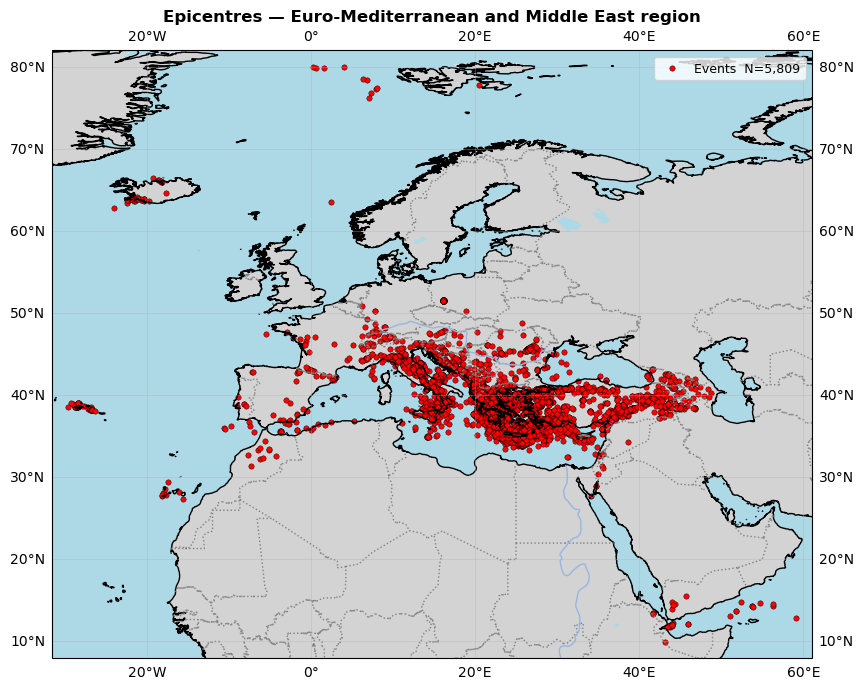

In [10]:
lons = unique_select_events['ev_longitude']
lats = unique_select_events['ev_latitude']

fig = plt.figure(figsize=(11, 7))
ax  = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'coastline', '10m', edgecolor='black', facecolor='none'))
ax.add_feature(cfeature.NaturalEarthFeature(
    'cultural', 'admin_0_boundary_lines_land', '10m',
    edgecolor='gray', facecolor='none', linestyle=':'))
ax.add_feature(cfeature.LAND,  facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')
ax.add_feature(cfeature.RIVERS)

ax.set_extent(
    [lons.min() - 2, lons.max() + 2, lats.min() - 2, lats.max() + 2],
    crs=ccrs.PlateCarree(),
)
ax.scatter(lons, lats, color='red', s=15, edgecolor='k', linewidths=0.3,
           label=f'Events  N={len(unique_select_events):,}')
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
ax.set_title(
    'Epicentres — Euro-Mediterranean and Middle East region',
    fontweight='bold',
)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/epicentre_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Annual event count

Bar chart of unique events per year for the selected study region.

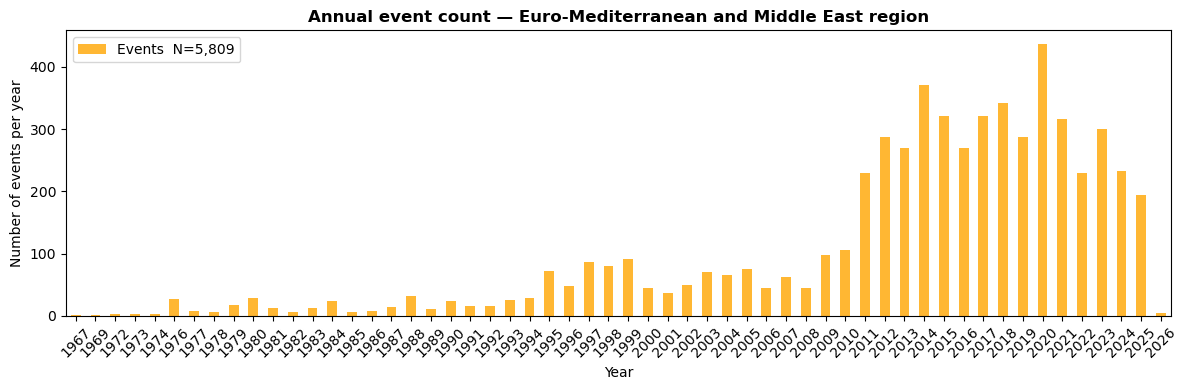

In [11]:
counts_per_year = unique_select_events['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
counts_per_year.plot(
    kind='bar', ax=ax, color='orange', alpha=0.8,
    label=f'Events  N={unique_select_events["esm_event_id"].nunique():,}',
)
ax.set_xlabel('Year')
ax.set_ylabel('Number of events per year')
ax.set_title(
    'Annual event count — Euro-Mediterranean and Middle East region',
    fontweight='bold',
)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/events_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Channel code distribution

Reports the unique `u`, `v`, `w` component channel codes found in the flatfile,
then plots waveform counts and percentage breakdown per channel for CV and MP subsets.

In [12]:
# Component channel code values in the flatfile
for comp in ('u', 'v', 'w'):
    vals = sorted(event_df[f'{comp}_channel_code'].dropna().unique())
    print(f'{comp}_channel_code : {vals}')

u_channel_code : ['1', '2', 'E']
v_channel_code : ['2', '3', 'N']
w_channel_code : ['3', 'Z']


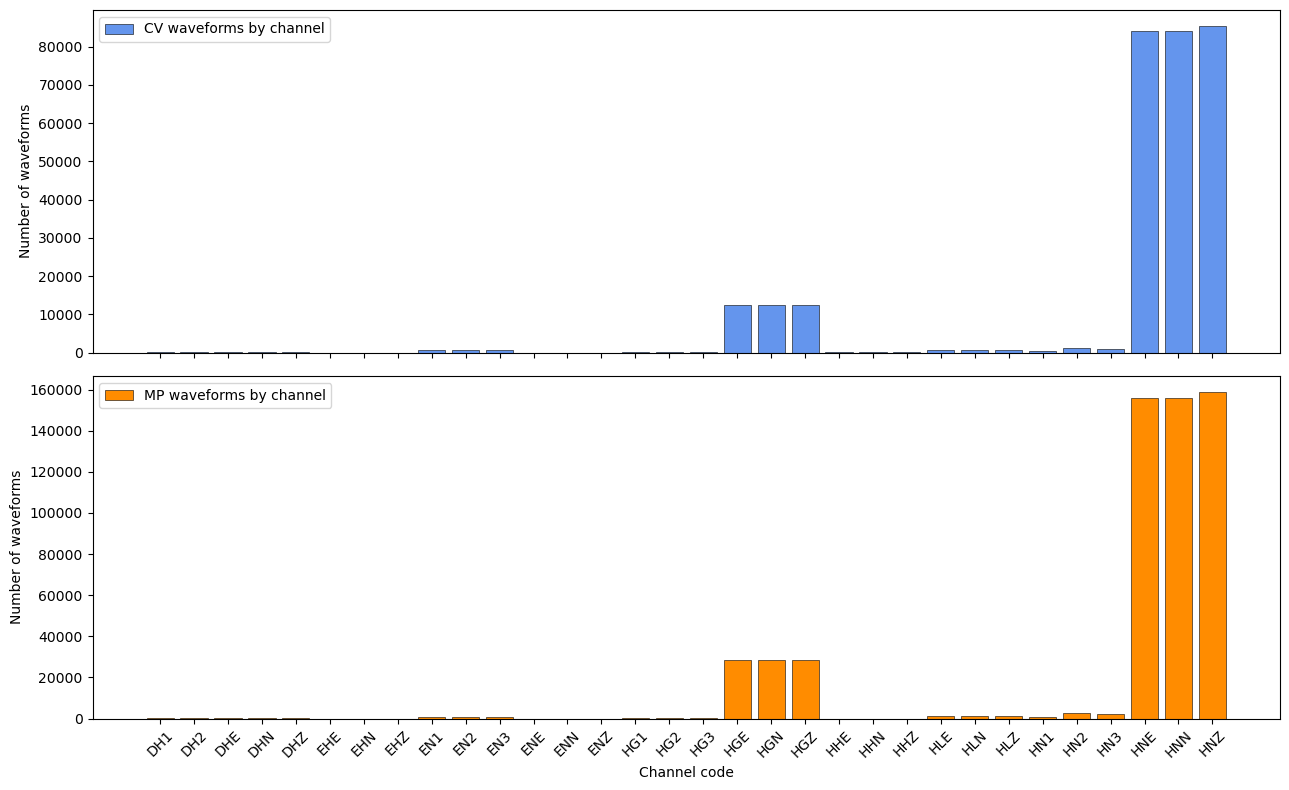

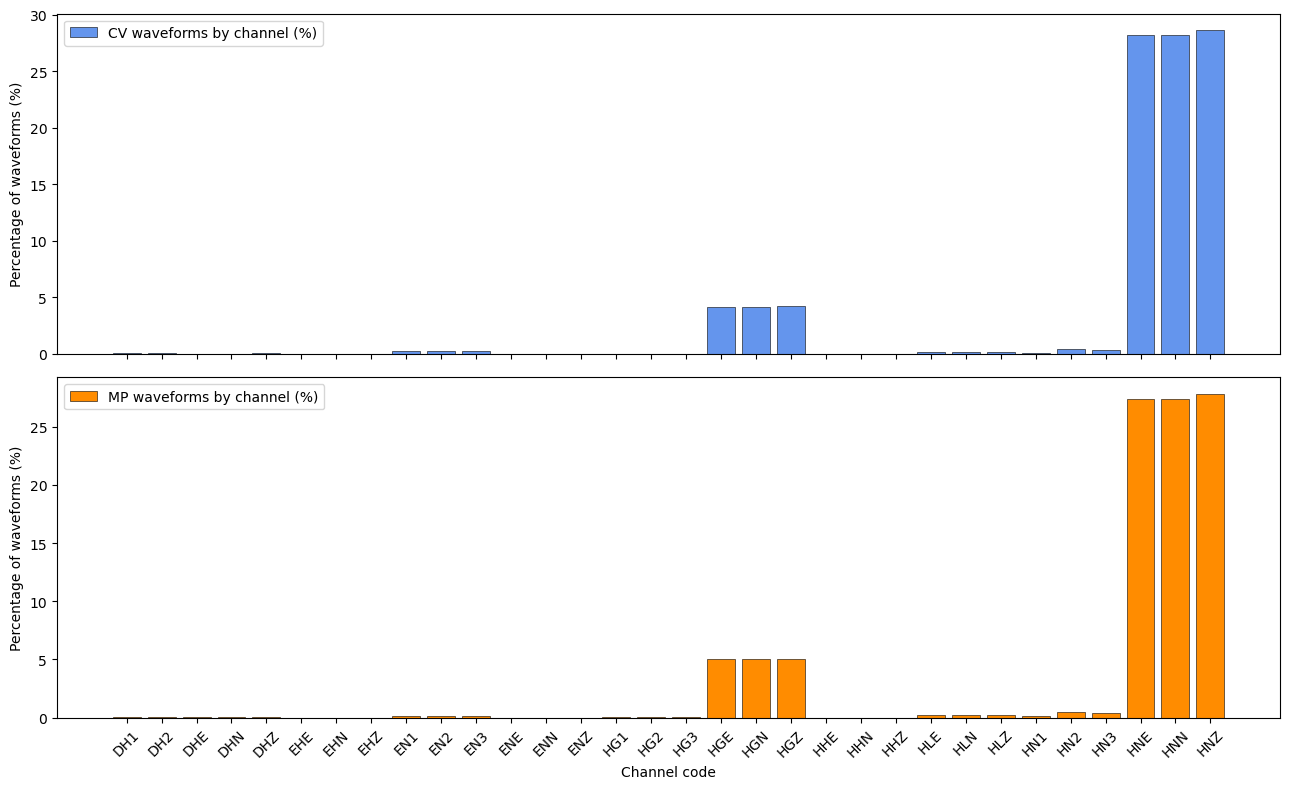

In [13]:
wave_cv = wave_select_df.loc[wave_select_df['processing'] == 'cv'].copy()
wave_mp = wave_select_df.loc[wave_select_df['processing'] == 'mp'].copy()


def ordered_channel_series(df: pd.DataFrame) -> pd.Series:
    """Return waveform counts per channel, sorted by code prefix then suffix."""
    ch  = df['channel'].astype(str)
    order = sorted(ch.unique(), key=lambda x: (x[:2], x[2:]))
    return ch.value_counts().reindex(order)


counts_cv = ordered_channel_series(wave_cv)
counts_mp = ordered_channel_series(wave_mp)

# ── Absolute counts ───────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, counts, label, color in zip(
    axs,
    [counts_cv, counts_mp],
    ['CV waveforms by channel', 'MP waveforms by channel'],
    ['cornflowerblue', 'darkorange'],
):
    ax.bar(counts.index, counts.values, color=color,
           edgecolor='black', linewidth=0.4, label=label)
    ax.set_ylabel('Number of waveforms')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
axs[1].set_xlabel('Channel code')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/waveforms_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Percentage breakdown ──────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, counts, label, color in zip(
    axs,
    [counts_cv, counts_mp],
    ['CV waveforms by channel (%)', 'MP waveforms by channel (%)'],
    ['cornflowerblue', 'darkorange'],
):
    pct = counts / counts.sum() * 100
    ax.bar(pct.index, pct.values, color=color,
           edgecolor='black', linewidth=0.4, label=label)
    ax.set_ylabel('Percentage of waveforms (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
axs[1].set_xlabel('Channel code')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/waveforms_by_channel_pct.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Waveform duration: statistics and threshold classification

Descriptive statistics for CV and MP duration. Waveforms exceeding the configured
duration thresholds (CV ≥ 400 s; MP ≥ 300 s) are exported for further inspection.

In [14]:
PCTS = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

print('── CV duration statistics (selected region) ───────────────────────────')
print(wave_cv['duration_sec'].describe(percentiles=PCTS).to_string())

print('\n── MP duration statistics (selected region) ───────────────────────────')
print(wave_mp['duration_sec'].describe(percentiles=PCTS).to_string())

print('\n── Full dataset (all events) ───────────────────────────────────────────')
print('CV:', wave_df.loc[wave_df['processing']=='cv', 'duration_sec'].describe(percentiles=PCTS).to_string())
print('MP:', wave_df.loc[wave_df['processing']=='mp', 'duration_sec'].describe(percentiles=PCTS).to_string())

── CV duration statistics (selected region) ───────────────────────────
count    297648.000000
mean        261.301773
std         120.498688
min           0.645000
10%          92.995000
25%         258.359000
50%         281.890000
75%         300.985000
90%         370.920000
95%         383.280000
99%         420.990000
max       18746.995000

── MP duration statistics (selected region) ───────────────────────────
count    569088.000000
mean        122.148458
std          55.750849
min           4.930000
10%          56.690000
25%          85.000000
50%         115.865000
75%         147.307500
90%         194.535000
95%         241.605000
99%         293.075000
max         699.985000

── Full dataset (all events) ───────────────────────────────────────────
CV: count    305193.000000
mean        261.453984
std         121.107651
min           0.645000
10%          89.995000
25%         257.750000
50%         282.025000
75%         302.385000
90%         372.635000
95%         385.31

In [15]:
# ── Threshold-based classification ───────────────────────────────────────────
wave_cv_long  = wave_cv.loc[wave_cv['duration_sec'] >= DURATION_THRESHOLD_CV]
wave_cv_short = wave_cv.loc[wave_cv['duration_sec'] <  DURATION_THRESHOLD_CV]

wave_mp_long  = wave_mp.loc[wave_mp['duration_sec'] >= DURATION_THRESHOLD_MP]
wave_mp_short = wave_mp.loc[wave_mp['duration_sec'] <  DURATION_THRESHOLD_MP]

print(f'CV ≥ {DURATION_THRESHOLD_CV} s : {len(wave_cv_long):,} traces  '
      f'({wave_cv_long["filename"].nunique():,} events)')
print(f'CV <  {DURATION_THRESHOLD_CV} s : {len(wave_cv_short):,} traces')
print(f'\nMP ≥ {DURATION_THRESHOLD_MP} s : {len(wave_mp_long):,} traces  '
      f'({wave_mp_long["filename"].nunique():,} events)')
print(f'MP <  {DURATION_THRESHOLD_MP} s : {len(wave_mp_short):,} traces')

# Export long MP waveforms for downstream analysis
wave_mp_long.to_csv('waveform_mp_long.csv', index=False)
print('\nSaved → waveform_mp_long.csv')

CV ≥ 400 s : 6,303 traces  (317 events)
CV <  400 s : 291,345 traces

MP ≥ 300 s : 3,663 traces  (113 events)
MP <  300 s : 565,425 traces

Saved → waveform_mp_long.csv


## 11. Waveform duration: histograms and violin plot

Visual comparison of duration distributions for CV and MP subsets.

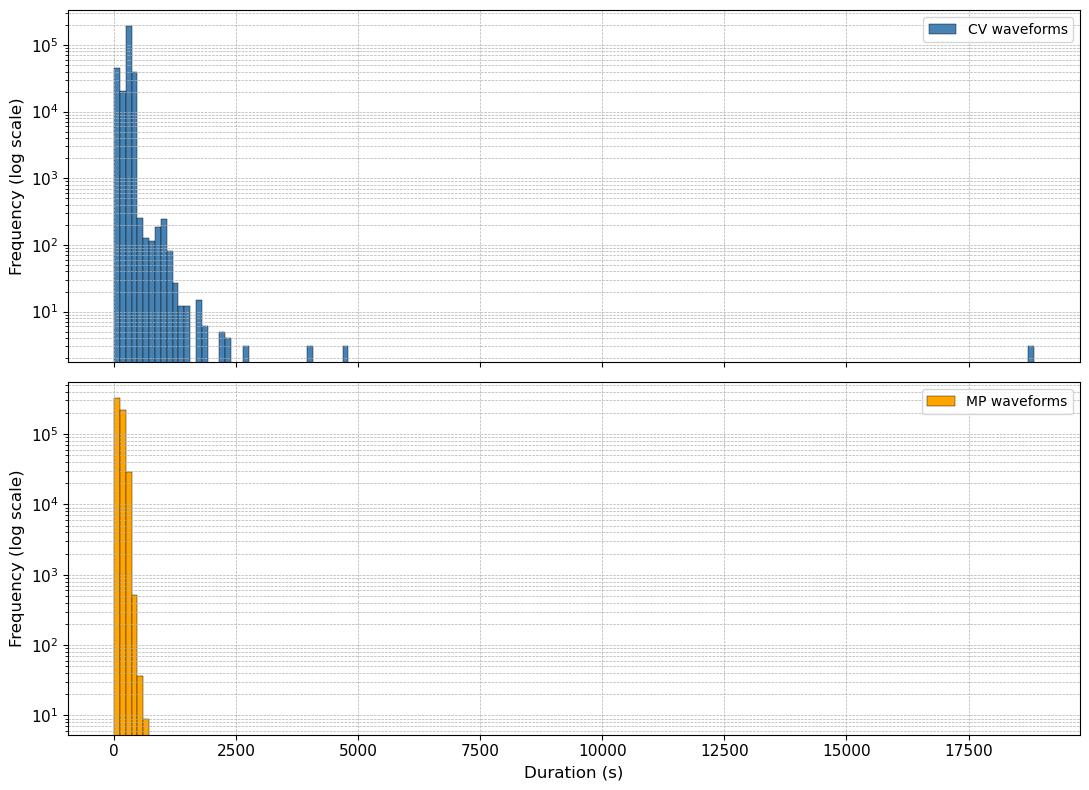

In [16]:
cv_dur = wave_select_df.loc[wave_select_df['processing'] == 'cv', 'duration_sec']
mp_dur = wave_select_df.loc[wave_select_df['processing'] == 'mp', 'duration_sec']

# ── Combined histogram (log scale, 120 s bins) ────────────────────────────────
max_dur = max(cv_dur.max(), mp_dur.max())
bins_combined = np.arange(0, max_dur + 120, 120)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, data, label, color in zip(
    axes,
    [cv_dur, mp_dur],
    ['CV waveforms', 'MP waveforms'],
    ['steelblue', 'orange'],
):
    ax.hist(data, bins=bins_combined, color=color, edgecolor='black',
            linewidth=0.3, log=True, label=label)
    ax.set_ylabel('Frequency (log scale)', fontsize=12)
    ax.legend(fontsize=10)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_xlabel('Duration (s)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/duration_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

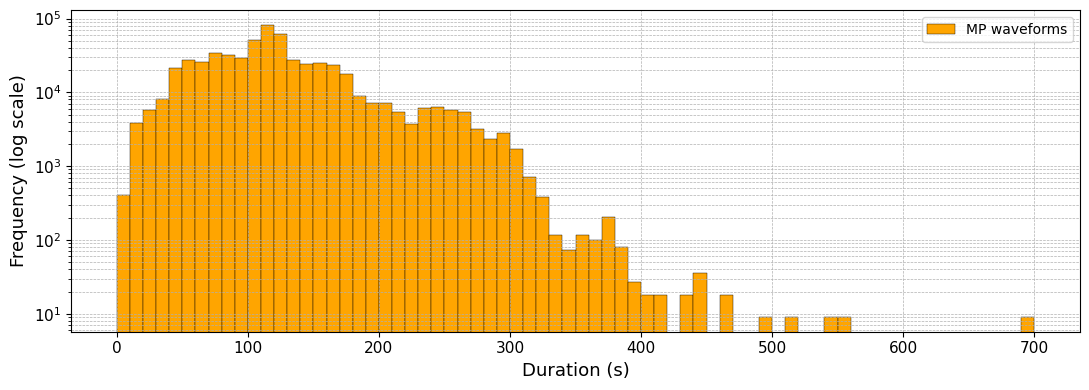

In [17]:
# ── MP only, fine-grained (10 s bins) ────────────────────────────────────────
bins_mp = np.arange(0, mp_dur.max() + 10, 10)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(mp_dur, bins=bins_mp, color='orange', edgecolor='black',
        linewidth=0.3, log=True, label='MP waveforms')
ax.set_xlabel('Duration (s)', fontsize=13)
ax.set_ylabel('Frequency (log scale)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/duration_histogram_mp.png', dpi=150, bbox_inches='tight')
plt.show()

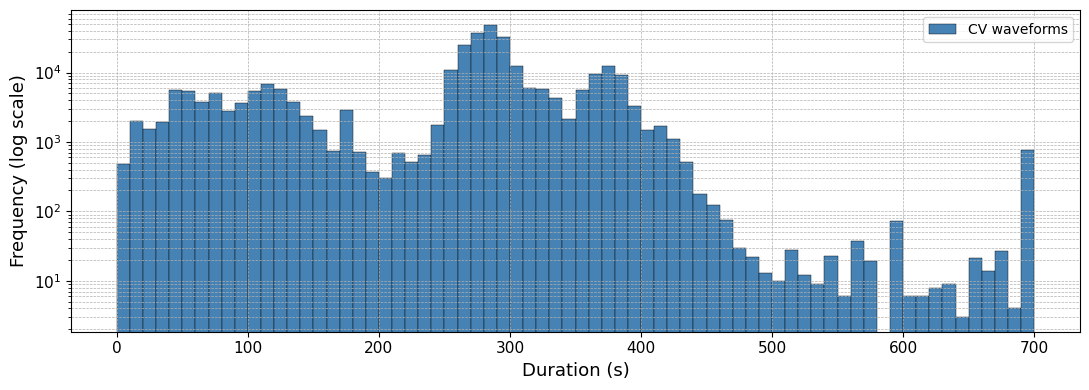

In [18]:
# ── CV only, fine-grained (10 s bins, capped at 700 s) ───────────────────────
bins_cv = np.arange(0, 710, 10)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(cv_dur.clip(upper=700), bins=bins_cv, color='steelblue',
        edgecolor='black', linewidth=0.3, log=True, label='CV waveforms')
ax.set_xlabel('Duration (s)', fontsize=13)
ax.set_ylabel('Frequency (log scale)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/duration_histogram_cv.png', dpi=150, bbox_inches='tight')
plt.show()

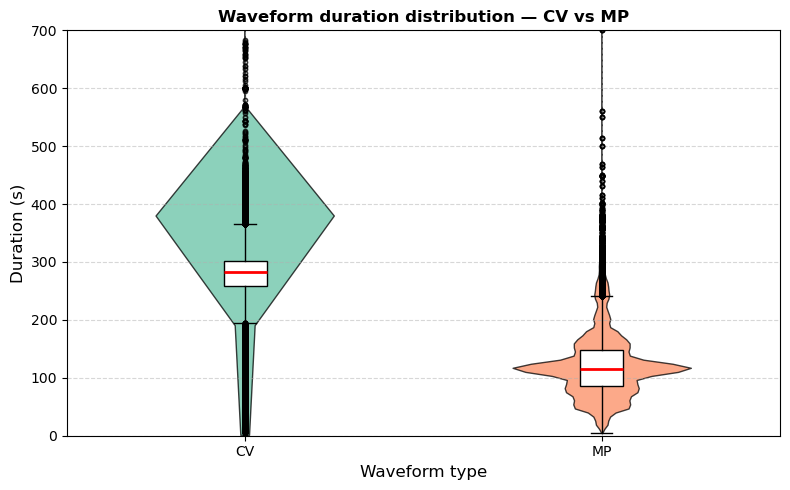

In [19]:
# ── Violin plot with embedded box plot ───────────────────────────────────────
df_violin = pd.DataFrame({
    'duration_sec': pd.concat([cv_dur, mp_dur], ignore_index=True),
    'dataset': ['CV'] * len(cv_dur) + ['MP'] * len(mp_dur),
})

fig, ax = plt.subplots(figsize=(8, 5))
cv_vals = df_violin.loc[df_violin['dataset'] == 'CV', 'duration_sec'].values
mp_vals = df_violin.loc[df_violin['dataset'] == 'MP', 'duration_sec'].values

parts = ax.violinplot(
    [cv_vals, mp_vals], positions=[1, 2],
    showmeans=False, showmedians=False, showextrema=False,
)
for pc, color in zip(parts['bodies'], ['#66c2a5', '#fc8d62']):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.75)

ax.boxplot(
    [cv_vals, mp_vals], positions=[1, 2], widths=0.12,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
ax.set_xticks([1, 2])
ax.set_xticklabels(['CV', 'MP'])
ax.set_ylim(0, 700)
ax.set_xlabel('Waveform type', fontsize=12)
ax.set_ylabel('Duration (s)', fontsize=12)
ax.set_title('Waveform duration distribution — CV vs MP', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/duration_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Sampling rate distribution

Counts CV waveform traces per sampling rate (whole dataset). A ±2 Hz tolerance
is applied to aggregate nominally identical values that differ due to floating-point
rounding. The y-axis uses a logarithmic scale.

Unique sampling rates (CV, rounded): [18.0, 25.0, 31.25, 50.0, 80.0, 83.0, 100.0, 100.04, 100.06, 120.0, 120.48, 125.0, 127.99, 128.0, 128.01, 152.21, 200.0, 250.0, 256.02, 300.03, 300.3, 343.64, 404.86, 409.84, 500.0, 1000.0]


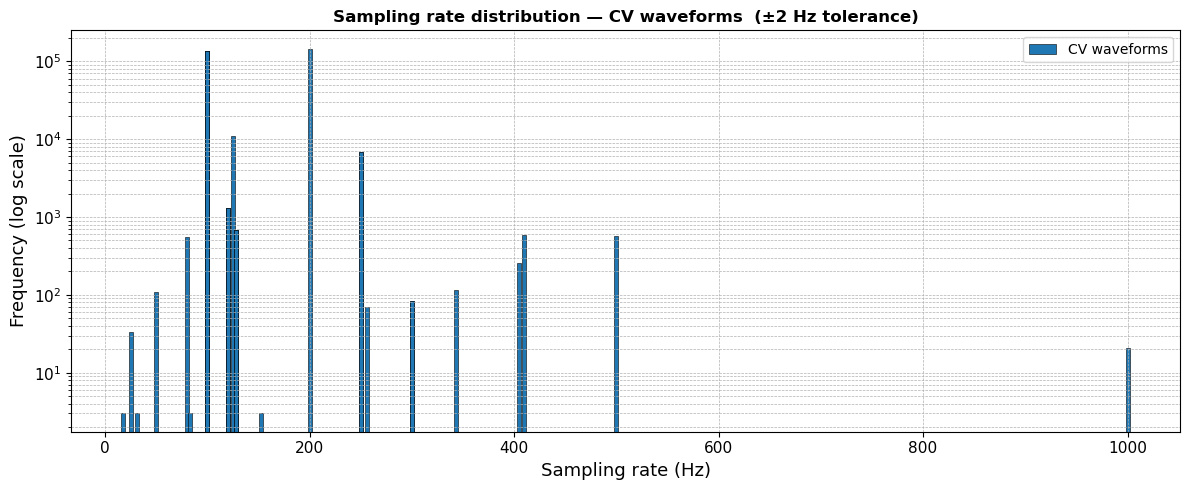

In [20]:
cv_sr     = wave_df.loc[wave_df['processing'] == 'cv', 'sampling_rate_hz']
unique_sr = np.sort(cv_sr.unique())
DELTA     = 2  # Hz grouping tolerance

sr_counts = [
    int(((cv_sr >= v - DELTA) & (cv_sr <= v + DELTA)).sum())
    for v in unique_sr
]

print('Unique sampling rates (CV, rounded):', sorted(cv_sr.round(2).unique()))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(unique_sr, sr_counts, width=2 * DELTA, align='center',
       edgecolor='black', linewidth=0.4, log=True, label='CV waveforms')
ax.set_xlabel('Sampling rate (Hz)', fontsize=13)
ax.set_ylabel('Frequency (log scale)', fontsize=13)
ax.set_title(f'Sampling rate distribution — CV waveforms  (±{DELTA} Hz tolerance)',
             fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/sampling_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Traces with epoch start-time (1970-01-01)

Traces whose `start_time` equals the Unix epoch have a missing or corrupted
time reference in the ASDF file. This section identifies and exports those
records for re-processing.

In [21]:
EPOCH = str(obspy.UTCDateTime('1970,01,01'))

# Whole dataset
wave_nostart_all = wave_df.loc[wave_df['start_time'] == EPOCH]
# Geographically selected region only
wave_nostart_sel = wave_select_df.loc[wave_select_df['start_time'] == EPOCH]

print('── All events ─────────────────────────────────────────────────────────')
print(f'  Epoch-start traces   : {len(wave_nostart_all):,}')
print(f'  Unique events        : {wave_nostart_all["filename"].nunique():,}')
print(f'  Unique stations      : {wave_nostart_all["station"].nunique():,}')

print('\n── Selected region ────────────────────────────────────────────────────')
print(f'  Epoch-start traces   : {len(wave_nostart_sel):,}')
print(f'  Unique events        : {wave_nostart_sel["filename"].nunique():,}')
print(f'  Unique stations      : {wave_nostart_sel["station"].nunique():,}')

# Save for re-download
unique_epoch_files = sorted(wave_nostart_sel['filename'].unique())
with open('filenames_epoch_start.txt', 'w') as fh:
    fh.writelines(fn + '\n' for fn in unique_epoch_files)

wave_nostart_sel.to_csv('waveform_epoch_start.csv', sep='|', index=False)
print(f'\nSaved → filenames_epoch_start.txt  ({len(unique_epoch_files)} files)')
print('Saved → waveform_epoch_start.csv')

── All events ─────────────────────────────────────────────────────────
  Epoch-start traces   : 0
  Unique events        : 0
  Unique stations      : 0

── Selected region ────────────────────────────────────────────────────
  Epoch-start traces   : 0
  Unique events        : 0
  Unique stations      : 0

Saved → filenames_epoch_start.txt  (0 files)
Saved → waveform_epoch_start.csv


## 14. Long-MP waveform impact on event-station coverage

If waveforms exceeding the duration threshold were to be removed, some events
would lose only a fraction of their stations while others would be dropped entirely.
This section quantifies that impact and produces a bar chart showing the
percentage of stations remaining per affected event.

In [22]:
# Simulate removal of long-MP traces and identify affected events
wave_df_filtered = wave_df.merge(
    wave_mp_long[['filename', 'station']],
    on=['filename', 'station'],
    how='left',
    indicator=True,
)
wave_df_reduced = wave_df_filtered[
    wave_df_filtered['_merge'] == 'left_only'
].drop(columns='_merge')

removed_set   = set(wave_mp_long['filename'].unique())
remaining_set = set(wave_df_reduced['filename'].unique())

partial_loss  = sorted(e for e in removed_set if e in remaining_set)
complete_loss = sorted(e for e in removed_set if e not in remaining_set)

print(f'Events losing some stations (partial loss)   : {len(partial_loss)}')
print(f'Events fully dropped (all stations removed)  : {len(complete_loss)}')

# Save affected event filenames
with open('events_affected_long_mp.txt', 'w') as fh:
    fh.writelines(fn + '\n' for fn in sorted(removed_set))
print('Saved → events_affected_long_mp.txt')

Events losing some stations (partial loss)   : 112
Events fully dropped (all stations removed)  : 1
Saved → events_affected_long_mp.txt


In [23]:
# Per-event station retention statistics
stations_orig = (
    wave_df.groupby('filename')['station'].unique().apply(set)
)
stations_rem = (
    wave_df_reduced.groupby('filename')['station'].unique().apply(set)
)

df_stats = stations_orig.to_frame('original').join(
    stations_rem.to_frame('remaining'), how='outer'
)
df_stats['original']  = df_stats['original'].apply(lambda x: x if isinstance(x, set) else set())
df_stats['remaining'] = df_stats['remaining'].apply(lambda x: x if isinstance(x, set) else set())
df_stats['n_original']  = df_stats['original'].apply(len)
df_stats['n_remaining'] = df_stats['remaining'].apply(len)
df_stats['pct_remaining'] = df_stats.apply(
    lambda r: 100 * r['n_remaining'] / r['n_original'] if r['n_original'] > 0 else 0.0,
    axis=1,
)

df_partial = (
    df_stats[df_stats['pct_remaining'] < 100]
    .sort_values('pct_remaining')
    .copy()
)
df_partial['n_removed'] = df_partial['n_original'] - df_partial['n_remaining']
print(f'Events with at least one station removed: {len(df_partial)}')

Events with at least one station removed: 113


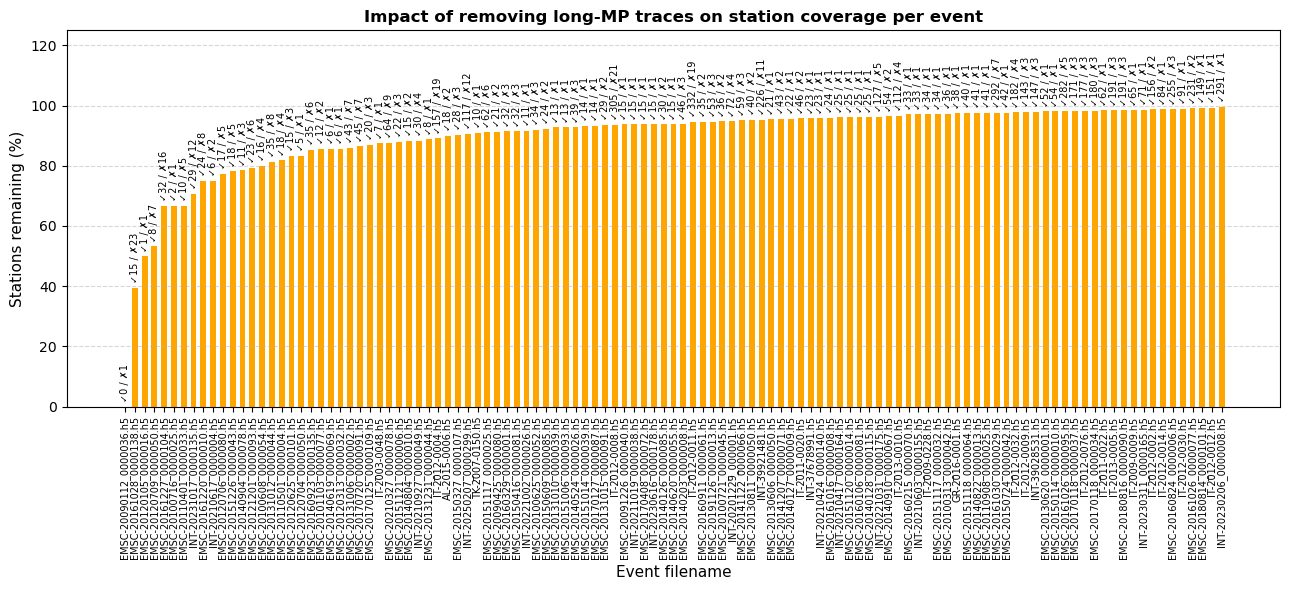

In [24]:
# Bar chart: % of stations remaining per affected event
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(df_partial.index, df_partial['pct_remaining'],
              color='orange', width=0.6)

for bar, n_rem, n_del in zip(
    bars, df_partial['n_remaining'], df_partial['n_removed']
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'✓{n_rem} / ✗{n_del}',
        ha='center', va='bottom', fontsize=7, rotation=90,
    )

ax.set_xlabel('Event filename', fontsize=11)
ax.set_ylabel('Stations remaining (%)', fontsize=11)
ax.set_title(
    'Impact of removing long-MP traces on station coverage per event',
    fontweight='bold',
)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 125)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/station_retention.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Three-component consistency check — CV

For each (event, station, channel-prefix) group in the CV dataset, verifies that all
three components share the same sampling rate **and** the same duration (in seconds).
Groups with any mismatch are exported to `cv_inconsistencies.csv`.

In [26]:
cv_check = wave_df.loc[wave_df['processing'] == 'cv'].copy()
cv_check['channel_prefix'] = cv_check['channel'].str[:2]

# Includi location_code nel groupby per distinguere installazioni diverse
# della stessa stazione (es. IU.DRLN.00 vs IU.DRLN.10)
cv_issues = []
for (filename, station, location, prefix), grp in cv_check.groupby(
        ['filename', 'station', 'location', 'channel_prefix']):
    if len(grp) < 3:
        continue  # skip incomplete component sets
    u_rates = grp['sampling_rate_hz'].round(6).unique()
    u_durs  = grp['duration_sec'].round(2).unique()
    if len(u_rates) > 1 or len(u_durs) > 1:
        cv_issues.append({
            'filename':          filename,
            'station':           station,
            'location':          location,
            'channel_prefix':    prefix,
            'sampling_rates_hz': list(u_rates),
            'durations_sec':     list(u_durs),
            'channels':          list(grp['channel']),
            'n_components':      len(grp),
        })

cv_issues_df = pd.DataFrame(cv_issues)
cv_issues_df.to_csv('cv_inconsistencies.csv', index=False)

print(f'CV groups with sampling-rate or duration mismatch: {len(cv_issues_df)}')
print('Saved → cv_inconsistencies.csv')
cv_issues_df.head()

CV groups with sampling-rate or duration mismatch: 18652
Saved → cv_inconsistencies.csv


,filename,station,location,channel_prefix,sampling_rates_hz,durations_sec,channels,n_components
0,AL-2014-0005.h5,AC.SDA,00,HN,[100.0],"[104.99, 105.99]","[HNE, HNN, HNZ]",3
1,AL-2014-0005.h5,HL.JAN,00,HN,[200.0],"[290.46, 288.38]","[HNE, HNN, HNZ]",3
2,AL-2014-0005.h5,HL.KASA,00,HN,[200.0],"[282.21, 284.27]","[HNE, HNN, HNZ]",3
3,AL-2015-0004.h5,HL.LXRA,00,HN,[200.0],"[252.08, 251.7, 251.84]","[HNE, HNN, HNZ]",3
4,AL-2015-0006.h5,HL.ARIA,00,HN,[200.0],"[284.27, 284.21]","[HNE, HNN, HNZ]",3


## 16. Three-component consistency check — MP

Same check as Section 15, applied to the MP (manually processed) dataset.
For MP, the tag also encodes the waveform quantity (`acc`, `vel`, `dis`),
which is extracted and used as an additional grouping key so that each
(event, station, channel-prefix, quantity) triple is checked independently.

In [29]:
mp_check = wave_df.loc[wave_df['processing'] == 'mp'].copy()
mp_check['channel_prefix'] = mp_check['channel'].str[:2]

_mp_re = re.compile(r'(acc|vel|dis)_mp')
mp_check['mp_type'] = mp_check['tag'].apply(
    lambda t: m.group(1) if (m := _mp_re.search(t)) else 'unknown'
)

mp_issues = []
for (filename, station, location, prefix, mp_type), grp in mp_check.groupby(
        ['filename', 'station', 'location', 'channel_prefix', 'mp_type']):
    if len(grp) < 3:
        continue
    u_rates = grp['sampling_rate_hz'].round(6).unique()
    u_durs  = grp['duration_sec'].round(2).unique()
    if len(u_rates) > 1 or len(u_durs) > 1:
        mp_issues.append({
            'filename':          filename,
            'station':           station,
            'location':          location,
            'channel_prefix':    prefix,
            'mp_type':           mp_type,
            'sampling_rates_hz': list(u_rates),
            'durations_sec':     list(u_durs),
            'channels':          list(grp['channel']),
            'n_components':      len(grp),
        })


mp_issues_df = pd.DataFrame(mp_issues)
mp_issues_df.to_csv('mp_inconsistencies.csv', index=False)

print(f'MP groups with mismatch: {len(mp_issues_df)}')
if not mp_issues_df.empty:
    print(f'  of which with 3 complete components: '
          f'{len(mp_issues_df.loc[mp_issues_df["n_components"] == 3])}')
print('Saved → mp_inconsistencies.csv')
mp_issues_df.head()

MP groups with mismatch: 0
Saved → mp_inconsistencies.csv


""


## 17. StationXML presence check

Loops over all HDF5 files and verifies that every station group contains a
valid StationXML entry (required to extract coordinates and instrument response).
Missing entries are written to `missing_stationxml_report.csv`.

> **Note:** This check opens every HDF5 file and may take several minutes
> on large datasets. Adjust the slice `all_h5_files[:]` to run on a subset.

In [ ]:
missing_stationxml = []

for fname in all_h5_files:   # replace with all_h5_files[:N] to test on a subset
    if not fname.endswith('.h5'):
        continue
    file_path = os.path.join(H5_DIR, fname)
    try:
        with pyasdf.ASDFDataSet(file_path, mode='r') as ds:
            for station in ds.waveforms.list():
                waveforms = ds.waveforms[station]
                try:
                    stationxml  = waveforms.StationXML
                    inv_station = stationxml[0][0]
                    _lat = inv_station.latitude    # noqa: access to verify presence
                    _lon = inv_station.longitude
                except Exception as e:
                    missing_stationxml.append({
                        'filename': fname,
                        'station':  station,
                        'error':    str(e),
                    })
    except Exception as e:
        missing_stationxml.append({'filename': fname, 'station': None, 'error': str(e)})

if missing_stationxml:
    df_missing = pd.DataFrame(missing_stationxml)
    df_missing.to_csv('missing_stationxml_report.csv', index=False)
    print(f'Stations without StationXML : {len(df_missing)}')
    print('Saved → missing_stationxml_report.csv')
else:
    print('✅ All StationXML entries found.')

## 18. Magnitude analysis

Derives two auxiliary columns:

- `magnitude` — the first non-NaN value from `MAG_COLS` (priority order).
- `magnitude_type` — the name of the magnitude scale that provided that value.

Then reports availability statistics and plots two pie charts.

In [ ]:
# ── Derive preferred magnitude and its type ───────────────────────────────────
event_df['magnitude'] = event_df[MAG_COLS].bfill(axis=1).iloc[:, 0]

def first_valid_col(row: pd.Series) -> str | float:
    """Return the name of the first non-NaN magnitude column, or NaN."""
    for col in MAG_COLS:
        if pd.notna(row[col]):
            return col
    return np.nan

event_df['magnitude_type'] = event_df[MAG_COLS].apply(first_valid_col, axis=1)

print('Preferred magnitude type distribution:')
print(event_df['magnitude_type'].value_counts(dropna=False).to_string())


In [ ]:
# ── Availability statistics: rows with each magnitude scale present ───────────
total_rows = len(event_df)

mag_stats = {
    col: int((event_df[col].notna() & (event_df[col] != 0)).sum())
    for col in MAG_COLS
}
df_mag_stats = pd.DataFrame.from_dict(
    mag_stats, orient='index', columns=['count']
)
df_mag_stats['percentage'] = df_mag_stats['count'] / total_rows * 100

print(f'Total rows: {total_rows:,}')
print(df_mag_stats.to_string())


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: preferred magnitude type (one entry per row)
type_counts = event_df['magnitude_type'].value_counts()
axes[0].pie(
    type_counts,
    labels=type_counts.index.str.upper(),
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
)
axes[0].set_title('Preferred magnitude type\n(one per record)', fontweight='bold')

# Right: availability (rows with each scale present, can exceed 100% in total)
axes[1].pie(
    df_mag_stats['count'],
    labels=df_mag_stats.index.str.upper(),
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
)
axes[1].set_title('Magnitude availability\n(records with value ≠ NaN / 0)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/magnitude_pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()


## 19. Magnitude vs epicentral distance

Scatter plot of preferred magnitude against epicentral distance for all
**processed** records. Points are coloured by magnitude type.
Only records with `epi_dist > 0` are shown (log scale on the x-axis).

In [ ]:
df_plot = (
    event_df[['epi_dist', 'magnitude', 'magnitude_type', 'processing_status']]
    .dropna(subset=['epi_dist', 'magnitude', 'magnitude_type'])
    .query('processing_status == "processed" and epi_dist > 0')
    .copy()
)

print(f'Records in plot: {len(df_plot):,}')

fig, ax = plt.subplots(figsize=(10, 6))
for mag_type, subset in df_plot.groupby('magnitude_type'):
    ax.scatter(
        subset['epi_dist'], subset['magnitude'],
        label=mag_type.upper(),
        alpha=0.5, s=15, edgecolors='none',
    )

ax.set_xscale('log')
ax.set_xlabel('Epicentral distance (km) — log scale', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title(
    'Magnitude vs epicentral distance — processed records',
    fontweight='bold',
)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(title='Magnitude type', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/magnitude_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()
